### 0. Content page

1. Load packages and data
2. Helper functions
3. Rebuild long / short / net returns
4. Core performance table
5. Cumulative performance plot: Long / Short / Net
6. Drawdown plot
7. Return histogram
8. Long vs short correlation and descriptive stats
9. Signal diagnostics: E/P and P/B
10. Universe size over time
11. Portfolio breadth over time
12. Long vs short composition
13. Benchmark comparison vs S&P 500
14. Turnover
15. A compact text summary cell for every model

### 1. Load packages and data

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

In [2]:
RESULT_DIR = "../tables/aqr_top1000_market_cap_top50_long_top50_short"
STRATEGY_NAME = "AQR Strategy"

In [3]:
portfolio_returns = pd.read_csv(f"{RESULT_DIR}/portfolio_returns.csv")
asset_returns = pd.read_csv(f"{RESULT_DIR}/asset_returns.csv")
weights_at_E = pd.read_csv(f"{RESULT_DIR}/weights_at_E.csv")
signals_at_T = pd.read_csv(f"{RESULT_DIR}/signals_at_T.csv")

try:
    portfolio_membership_at_T = pd.read_csv(f"{RESULT_DIR}/portfolio_membership_at_T.csv")
except FileNotFoundError:
    portfolio_membership_at_T = None

In [4]:
for c in ["signal_date", "execution_date", "next_execution_date"]:
    if c in portfolio_returns.columns:
        portfolio_returns[c] = pd.to_datetime(portfolio_returns[c])

for c in ["signal_date", "execution_date", "next_execution_date", "actual_exit_date"]:
    if c in asset_returns.columns:
        asset_returns[c] = pd.to_datetime(asset_returns[c])

for c in ["signal_date", "execution_date"]:
    if c in weights_at_E.columns:
        weights_at_E[c] = pd.to_datetime(weights_at_E[c])

if "signal_date" in signals_at_T.columns:
    signals_at_T["signal_date"] = pd.to_datetime(signals_at_T["signal_date"])

if portfolio_membership_at_T is not None:
    for c in ["signal_date", "execution_date"]:
        if c in portfolio_membership_at_T.columns:
            portfolio_membership_at_T[c] = pd.to_datetime(portfolio_membership_at_T[c])

In [5]:
print("portfolio_returns:", portfolio_returns.shape)
print("asset_returns:", asset_returns.shape)
print("weights_at_E:", weights_at_E.shape)
print("signals_at_T:", signals_at_T.shape)
if portfolio_membership_at_T is not None:
    print("portfolio_membership_at_T:", portfolio_membership_at_T.shape)

portfolio_returns: (238, 4)
asset_returns: (23798, 11)
weights_at_E: (23798, 22)
signals_at_T: (233477, 18)
portfolio_membership_at_T: (23798, 21)


### 2. Helper functions

In [6]:
def annualized_sharpe(monthly_returns: pd.Series) -> float:
    monthly_returns = monthly_returns.dropna()
    if len(monthly_returns) == 0 or monthly_returns.std() == 0:
        return np.nan
    return monthly_returns.mean() / monthly_returns.std() * np.sqrt(12)

def max_drawdown(return_series: pd.Series) -> float:
    cum = (1 + return_series.fillna(0)).cumprod()
    roll_max = cum.cummax()
    drawdown = cum / roll_max - 1
    return drawdown.min()

def performance_summary(return_series: pd.Series) -> pd.Series:
    return pd.Series({
        "mean_monthly": return_series.mean(),
        "vol_monthly": return_series.std(),
        "ann_sharpe": annualized_sharpe(return_series),
        "positive_month_pct": (return_series > 0).mean(),
        "max_drawdown": max_drawdown(return_series),
    })

### 3. Rebuild long / short / net returns

In [7]:
monthly_side = (
    asset_returns.groupby(
        ["signal_date", "execution_date", "next_execution_date", "side"],
        as_index=False
    )["weighted_return"]
    .sum()
)

monthly_side_pivot = (
    monthly_side.pivot(
        index=["signal_date", "execution_date", "next_execution_date"],
        columns="side",
        values="weighted_return"
    )
    .reset_index()
)

monthly_side_pivot.columns.name = None

if "long" not in monthly_side_pivot.columns:
    monthly_side_pivot["long"] = 0.0
if "short" not in monthly_side_pivot.columns:
    monthly_side_pivot["short"] = 0.0

monthly_side_pivot["net"] = monthly_side_pivot["long"] + monthly_side_pivot["short"]
monthly_side_pivot.head()

,signal_date,execution_date,next_execution_date,long,short,net
0,2006-02-28,2006-03-01,2006-04-03,0.007552,-0.014896,-0.007344
1,2006-03-31,2006-04-03,2006-05-01,0.006458,-0.009392,-0.002934
2,2006-04-28,2006-05-01,2006-06-01,-0.011242,0.032701,0.021460
3,2006-05-31,2006-06-01,2006-07-03,0.000916,0.028079,0.028994
4,2006-06-30,2006-07-03,2006-08-01,-0.005690,0.039370,0.033679


In [8]:
check = portfolio_returns.merge(
    monthly_side_pivot[["signal_date", "execution_date", "next_execution_date", "net"]],
    on=["signal_date", "execution_date", "next_execution_date"],
    how="inner"
)

check["diff"] = check["portfolio_return"] - check["net"]

print("max abs diff:", check["diff"].abs().max())
print("nonzero diff rows:", (check["diff"].abs() > 1e-12).sum())

max abs diff: 3.4139358007223564e-15
nonzero diff rows: 0


### 4. Core performance table

In [9]:
summary_table = pd.DataFrame({
    "long_leg": performance_summary(monthly_side_pivot["long"]),
    "short_leg": performance_summary(monthly_side_pivot["short"]),
    "net_portfolio": performance_summary(monthly_side_pivot["net"]),
}).T

summary_table

,mean_monthly,vol_monthly,ann_sharpe,positive_month_pct,max_drawdown
long_leg,0.004121,0.029640,0.481691,0.621849,-0.349594
short_leg,-0.003309,0.043358,-0.264387,0.436975,-0.805636
net_portfolio,0.000812,0.031150,0.090337,0.516807,-0.543560


### 5. Cumulative performance plot: Long / Short / Net

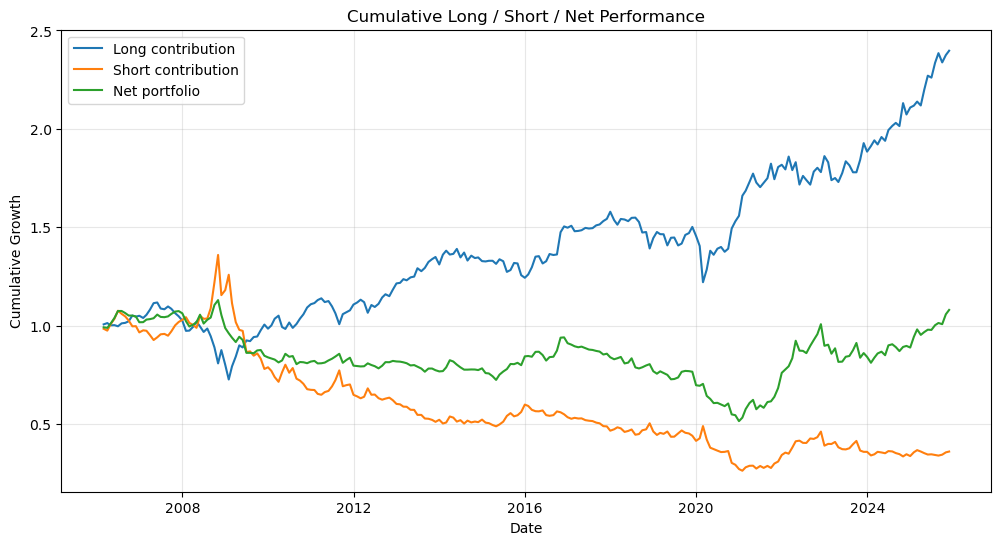

In [10]:
plot_df = monthly_side_pivot.sort_values("signal_date").copy()
plot_df["cum_long"] = (1 + plot_df["long"]).cumprod()
plot_df["cum_short"] = (1 + plot_df["short"]).cumprod()
plot_df["cum_net"] = (1 + plot_df["net"]).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(plot_df["signal_date"], plot_df["cum_long"], label="Long contribution")
plt.plot(plot_df["signal_date"], plot_df["cum_short"], label="Short contribution")
plt.plot(plot_df["signal_date"], plot_df["cum_net"], label="Net portfolio")
plt.title("Cumulative Long / Short / Net Performance")
plt.xlabel("Date")
plt.ylabel("Cumulative Growth")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 6. Drawdown plot

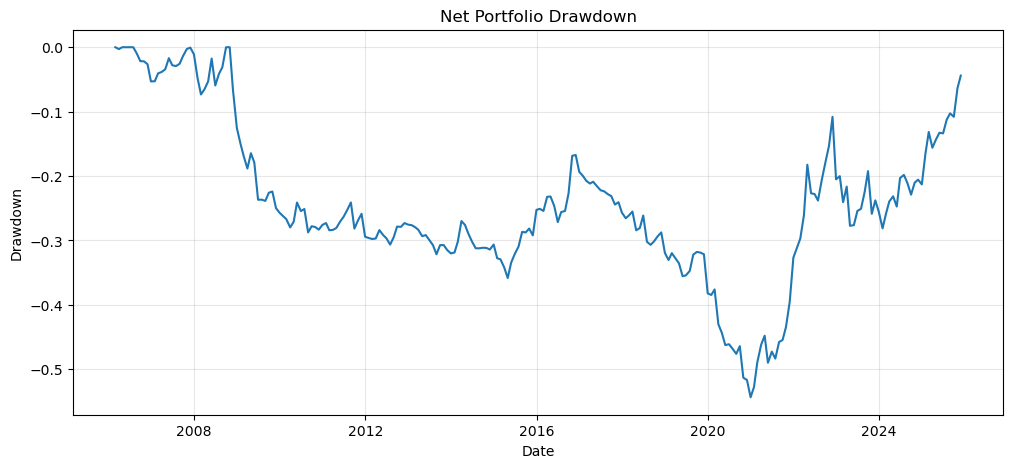

In [11]:
drawdown_df = plot_df[["signal_date", "net"]].copy()
drawdown_df["cum"] = (1 + drawdown_df["net"]).cumprod()
drawdown_df["roll_max"] = drawdown_df["cum"].cummax()
drawdown_df["drawdown"] = drawdown_df["cum"] / drawdown_df["roll_max"] - 1

plt.figure(figsize=(12, 5))
plt.plot(drawdown_df["signal_date"], drawdown_df["drawdown"])
plt.title("Net Portfolio Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.grid(True, alpha=0.3)
plt.show()

### 7. Return histogram

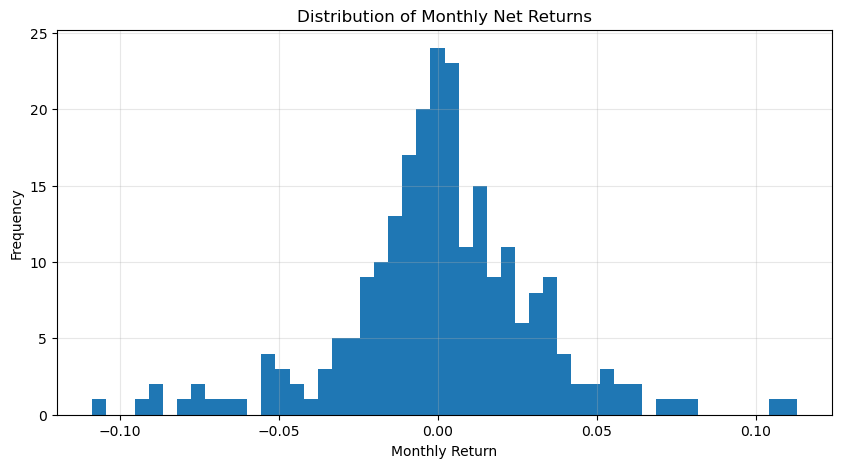

In [12]:
plt.figure(figsize=(10, 5))
plt.hist(monthly_side_pivot["net"], bins=50)
plt.title("Distribution of Monthly Net Returns")
plt.xlabel("Monthly Return")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.show()

### 8. Long vs short correlation and descriptive stats

In [13]:
monthly_side_pivot[["long", "short", "net"]].describe()

,long,short,net
count,238.000000,238.000000,238.000000
mean,0.004121,-0.003309,0.000812
std,0.029640,0.043358,0.031150
min,-0.130902,-0.165192,-0.108794
25%,-0.011437,-0.024901,-0.012880
50%,0.006440,-0.004678,0.000518
75%,0.021253,0.020715,0.016634
max,0.091888,0.144833,0.112965


In [14]:
print("Long-short monthly return correlation:", monthly_side_pivot["long"].corr(monthly_side_pivot["short"]))

Long-short monthly return correlation: -0.6956924772441879


### 9. Signal diagnostics: E/P and P/B

In [15]:
signal_cols_to_check = [
    c for c in [
        "value_signal",
        "quality_signal",
        "momentum_signal",
        "book_equity",
        "market_cap",
        "revenue",
        "operatingIncome",
        "mom_1m"
    ]
    if c in weights_at_E.columns
]

signal_cols_to_check

['value_signal',
 'quality_signal',
 'momentum_signal',
 'book_equity',
 'market_cap',
 'revenue',
 'operatingIncome',
 'mom_1m']

In [16]:
for col in signal_cols_to_check:
    print(f"\n=== {col} ===")
    display(weights_at_E[col].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))


=== value_signal ===


count    2.379800e+04
mean     1.026650e+01
std      1.396790e+02
min      2.649723e-08
1%       1.043801e-04
5%       7.031983e-03
50%      3.736636e-01
95%      1.601004e+00
99%      3.328015e+01
max      6.146444e+03
Name: value_signal, dtype: float64


=== quality_signal ===


count    23798.000000
mean        -0.104333
std          4.450143
min       -184.279355
1%          -6.897882
5%          -1.390685
50%          0.121499
95%          0.599717
99%          0.975407
max        329.485606
Name: quality_signal, dtype: float64


=== momentum_signal ===


...

count    2.379800e+04
mean     4.801386e+10
std      7.018265e+11
min      1.003973e+06
1%       1.911299e+06
5%       8.045469e+06
50%      4.890510e+08
95%      1.719300e+10
99%      3.375500e+11
max      2.806365e+13
Name: revenue, dtype: float64


=== operatingIncome ===


count    2.379800e+04
mean     1.509903e+10
std      2.477803e+11
min     -1.829200e+10
1%      -4.857917e+08
5%      -9.633985e+07
50%      6.502200e+07
95%      3.745000e+09
99%      7.397562e+10
max      7.373152e+12
Name: operatingIncome, dtype: float64


=== mom_1m ===


count    23798.000000
mean        -0.002878
std          0.132810
min         -0.976400
1%          -0.354382
5%          -0.220071
50%          0.004124
95%          0.190652
99%          0.329788
max          1.754735
Name: mom_1m, dtype: float64

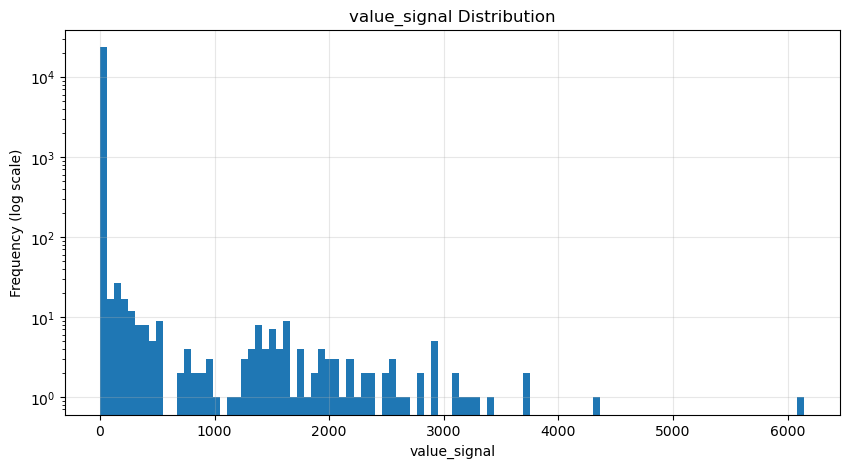

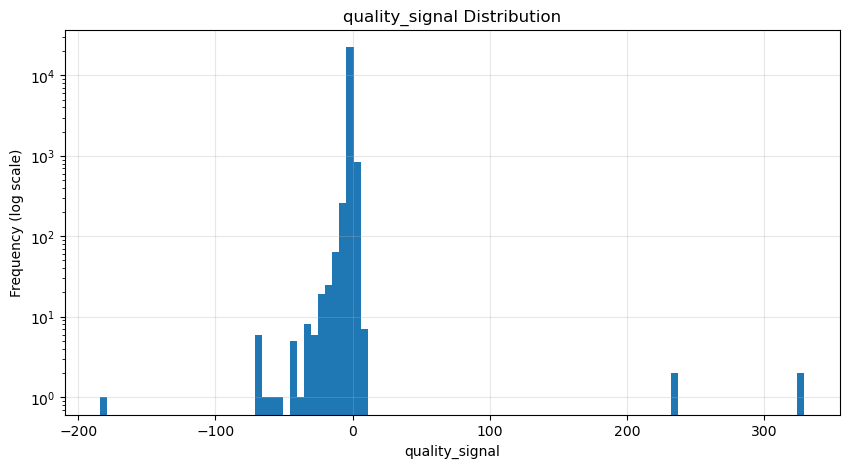

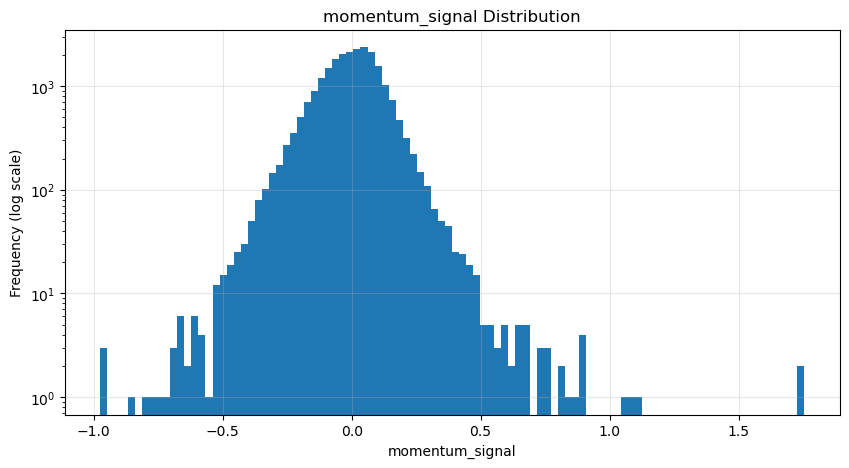

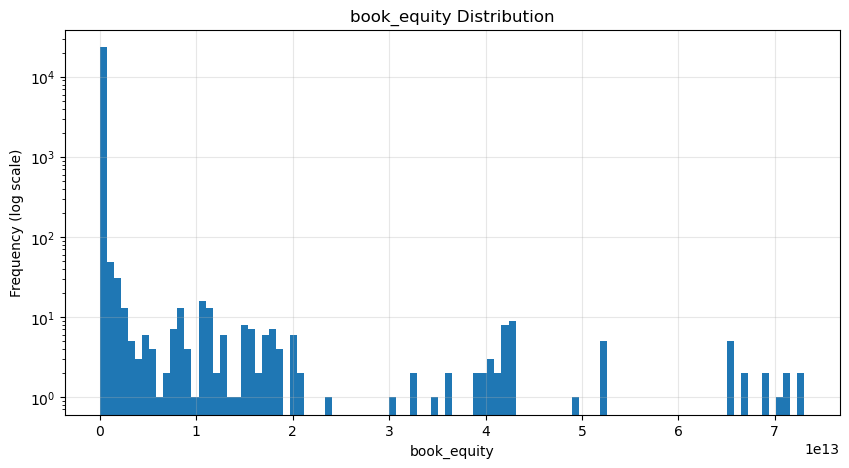

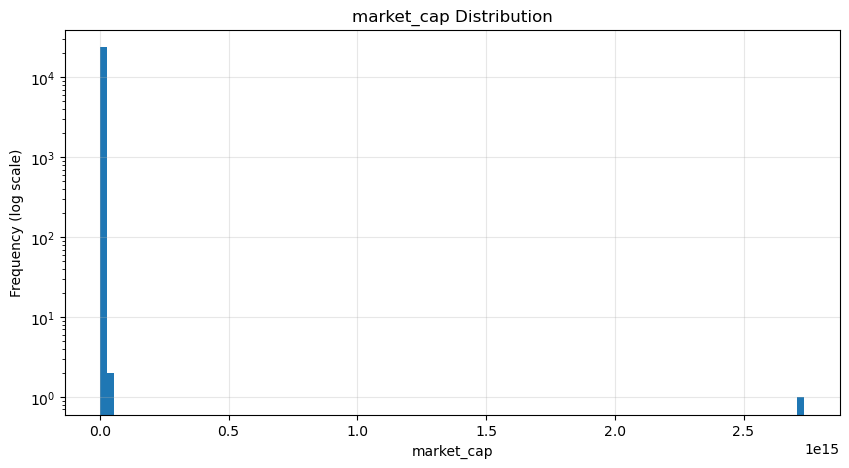

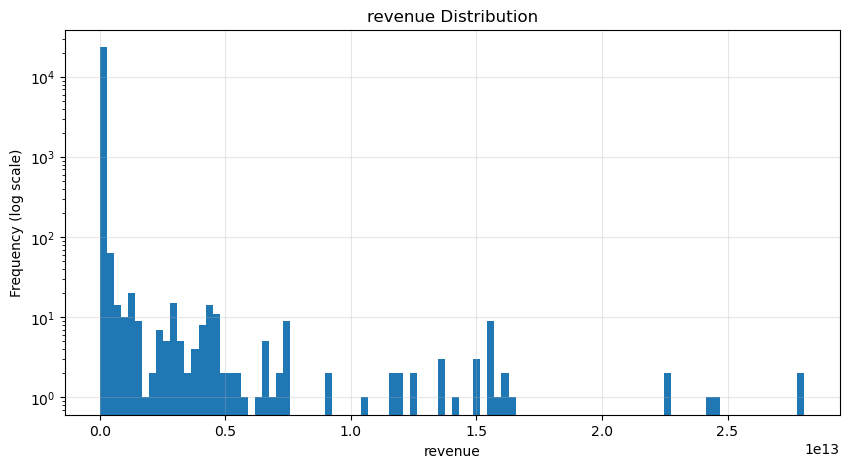

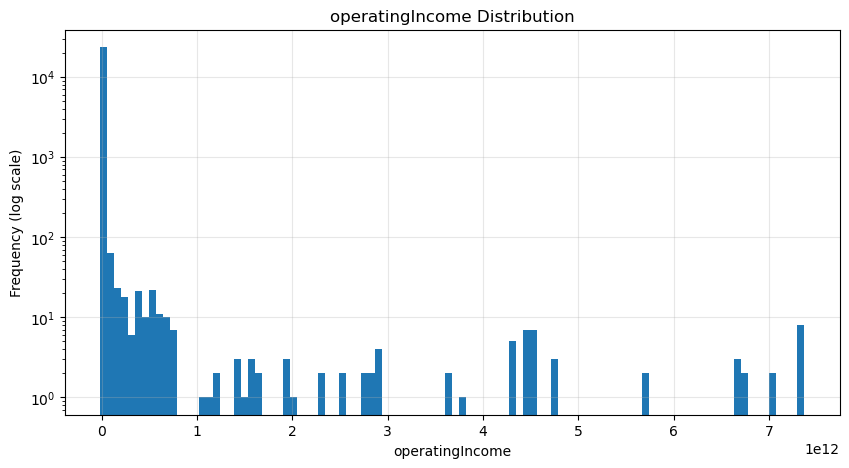

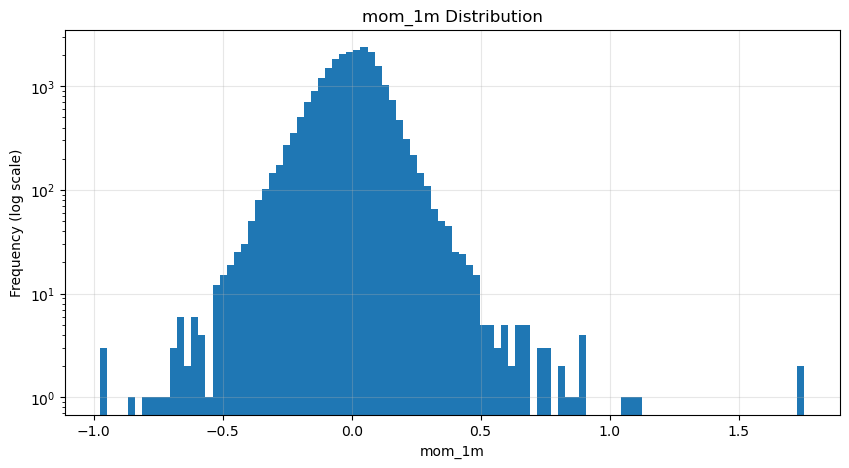

In [17]:
for col in signal_cols_to_check:
    plt.figure(figsize=(10, 5))
    plt.hist(weights_at_E[col].dropna(), bins=100)
    plt.yscale("log")
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Frequency (log scale)")
    plt.grid(True, alpha=0.3)
    plt.show()

### 10. Universe size over time

In [18]:
universe_size = (
    signals_at_T.groupby("signal_date")["ticker"]
    .nunique()
    .reset_index(name="n_universe")
)

universe_size.head()

,signal_date,n_universe
0,2006-02-28,980
1,2006-03-31,975
2,2006-04-28,974
3,2006-05-31,978
4,2006-06-30,981


In [19]:
universe_size["n_universe"].describe()

count    238.000000
mean     980.995798
std        5.943118
min      955.000000
25%      978.000000
50%      982.000000
75%      985.000000
max      992.000000
Name: n_universe, dtype: float64

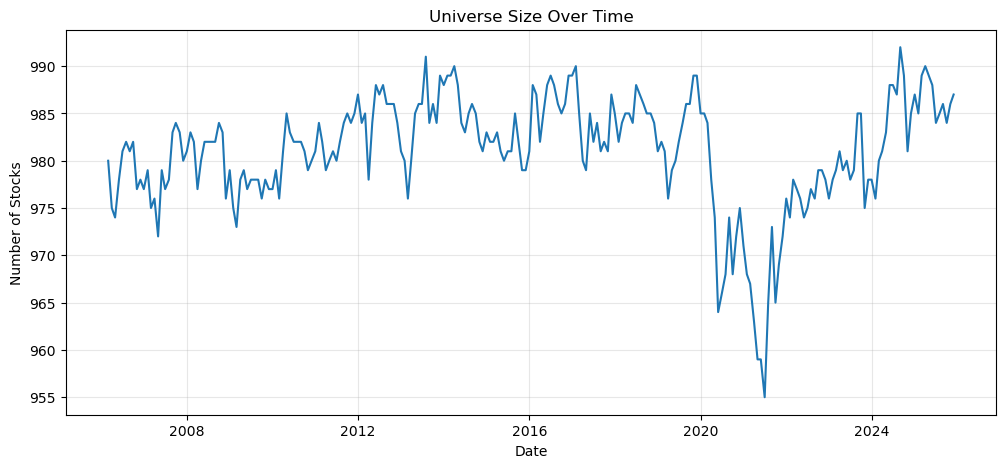

In [20]:
plt.figure(figsize=(12, 5))
plt.plot(universe_size["signal_date"], universe_size["n_universe"])
plt.title("Universe Size Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Stocks")
plt.grid(True, alpha=0.3)
plt.show()

### 11. Portfolio breadth over time

In [21]:
breadth = (
    asset_returns.groupby(["signal_date", "side"])["ticker"]
    .nunique()
    .reset_index()
)

breadth_pivot = breadth.pivot(index="signal_date", columns="side", values="ticker").reset_index()
breadth_pivot.columns.name = None

if "long" not in breadth_pivot.columns:
    breadth_pivot["long"] = np.nan
if "short" not in breadth_pivot.columns:
    breadth_pivot["short"] = np.nan

breadth_pivot.head()

,signal_date,long,short
0,2006-02-28,50,50
1,2006-03-31,50,50
2,2006-04-28,50,50
3,2006-05-31,50,50
4,2006-06-30,50,50


In [22]:
breadth_pivot[["long", "short"]].describe()

,long,short
count,238.0,238.000000
mean,50.0,49.991597
std,0.0,0.091476
min,50.0,49.000000
25%,50.0,50.000000
50%,50.0,50.000000
75%,50.0,50.000000
max,50.0,50.000000


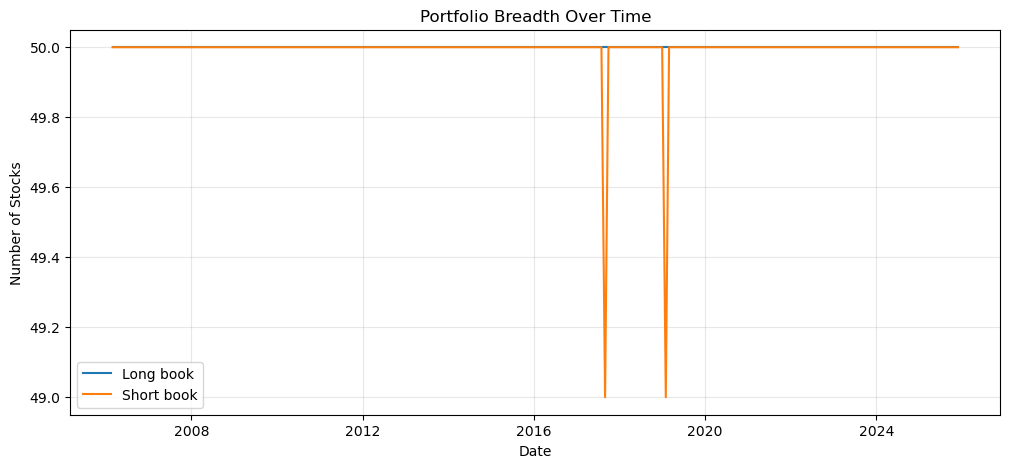

In [23]:
plt.figure(figsize=(12, 5))
plt.plot(breadth_pivot["signal_date"], breadth_pivot["long"], label="Long book")
plt.plot(breadth_pivot["signal_date"], breadth_pivot["short"], label="Short book")
plt.title("Portfolio Breadth Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Stocks")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 12. Long vs short composition

In [24]:
factor_cols = [
    c for c in [
        "market_cap",
        "book_equity",
        "revenue",
        "operatingIncome",
        "value_signal",
        "quality_signal",
        "momentum_signal",
        "mom_1m"
    ]
    if c in weights_at_E.columns
]

factor_cols

['market_cap',
 'book_equity',
 'revenue',
 'operatingIncome',
 'value_signal',
 'quality_signal',
 'momentum_signal',
 'mom_1m']

In [25]:
factor_summary = (
    weights_at_E.groupby("side")[factor_cols]
    .mean()
    .T
)

factor_summary

side,long,short
market_cap,2.170787e+10,3.279085e+11
book_equity,3.729410e+11,1.478422e+09
revenue,9.395922e+10,2.060778e+09
operatingIncome,3.017205e+10,2.347071e+07
value_signal,2.040400e+01,1.272943e-01
quality_signal,4.599344e-01,-6.686948e-01
momentum_signal,8.750848e-02,-9.327901e-02
mom_1m,8.750848e-02,-9.327901e-02


In [26]:
factor_check = (
    weights_at_E.groupby(["signal_date", "side"])[factor_cols]
    .mean()
    .reset_index()
)

factor_check.head()

,signal_date,side,market_cap,book_equity,revenue,operatingIncome,value_signal,quality_signal,momentum_signal,mom_1m
0,2006-02-28,long,1.833105e+10,9.026194e+11,1.539801e+11,1.413267e+11,36.133459,0.278302,0.063564,0.063564
1,2006-02-28,short,6.403686e+09,7.365207e+08,8.383814e+08,1.860871e+07,0.140425,-0.828975,-0.069509,-0.069509
2,2006-03-31,long,5.519239e+09,1.594764e+11,9.238574e+10,9.598571e+10,18.080955,5.120226,0.078254,0.078254
3,2006-03-31,short,6.813093e+09,7.551055e+08,8.204403e+08,-2.915827e+07,0.144113,-1.092306,-0.051217,-0.051217
4,2006-04-28,long,2.686801e+10,1.028793e+12,2.797371e+11,2.351521e+11,47.389776,5.151509,0.082405,0.082405


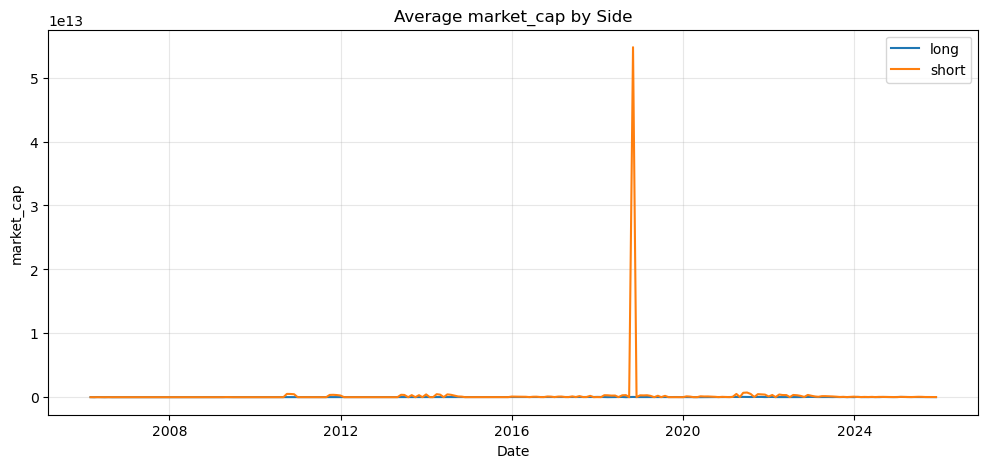

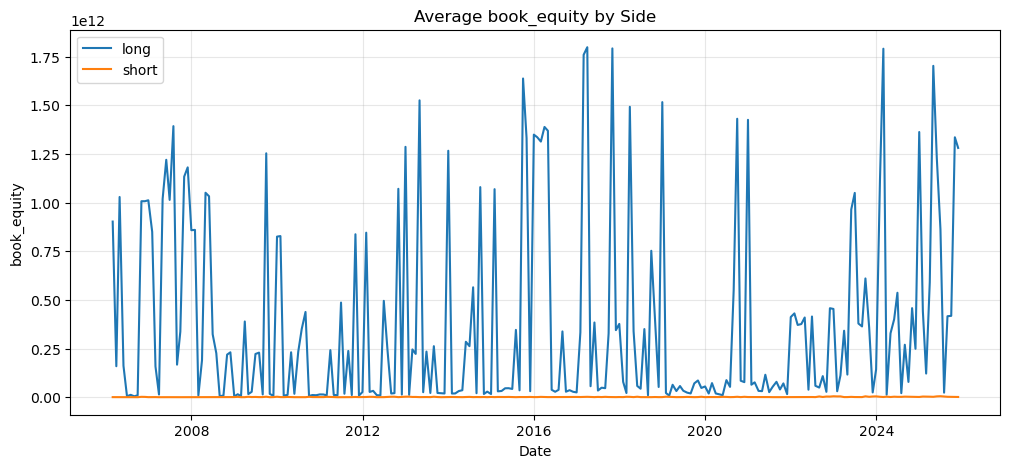

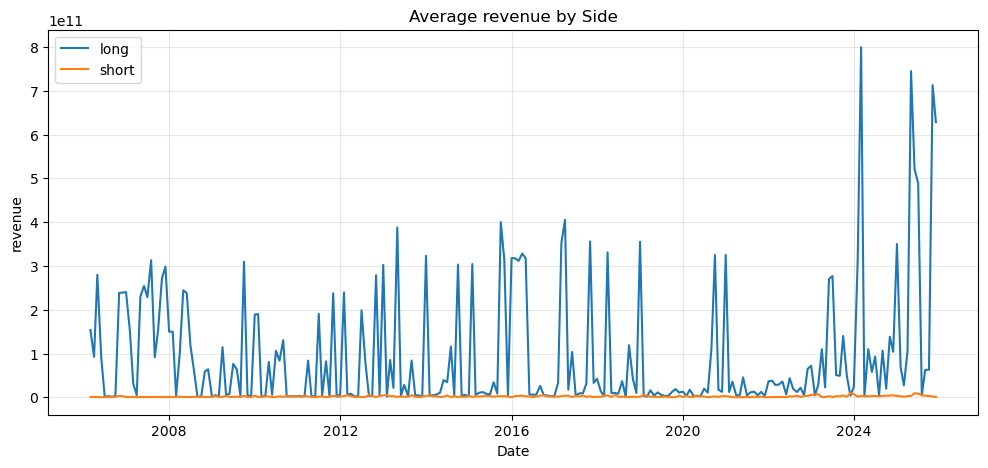

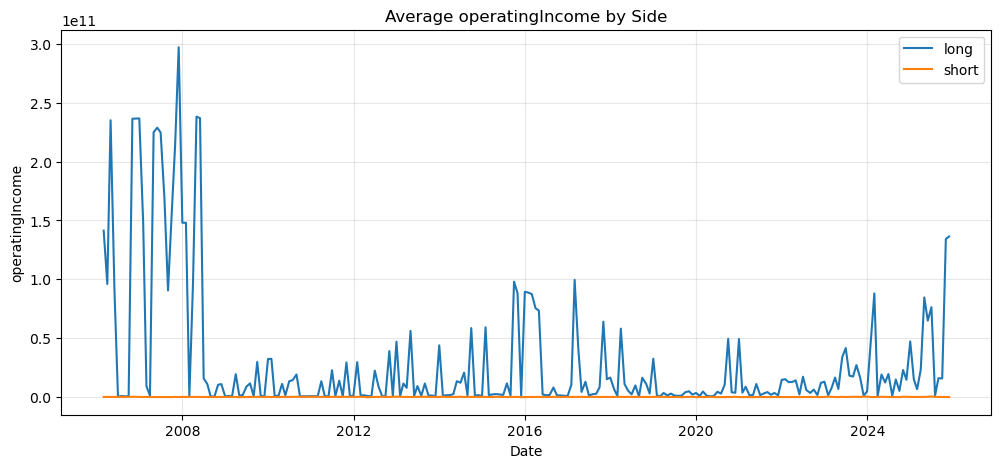

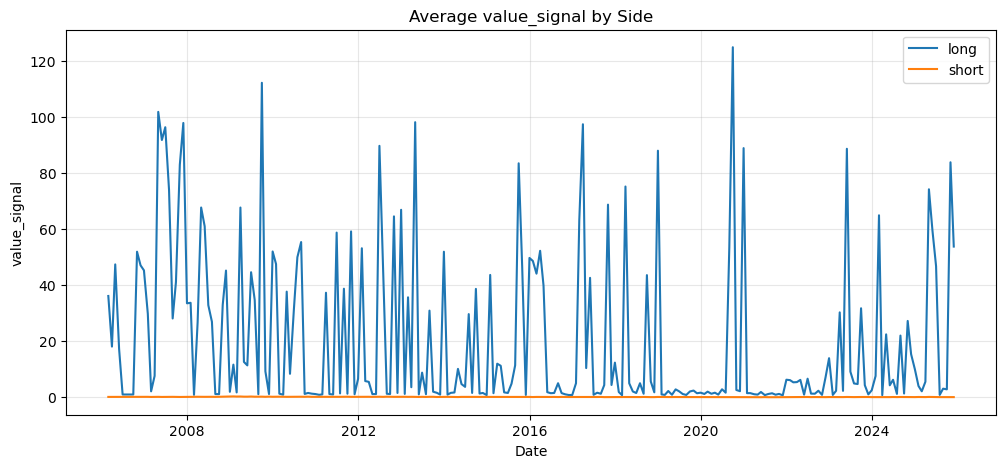

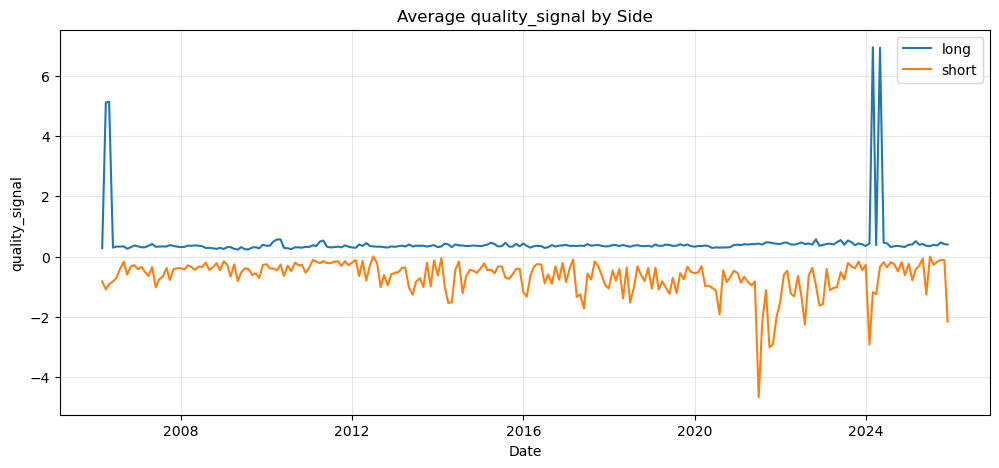

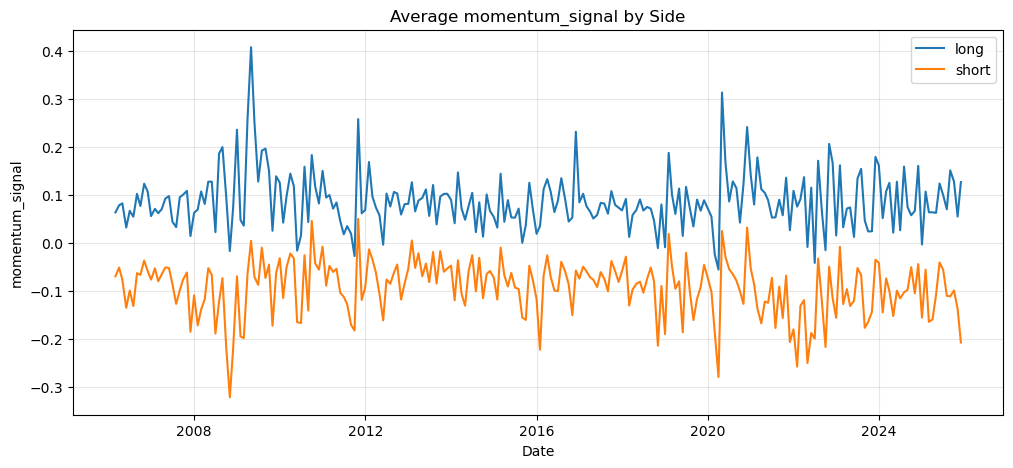

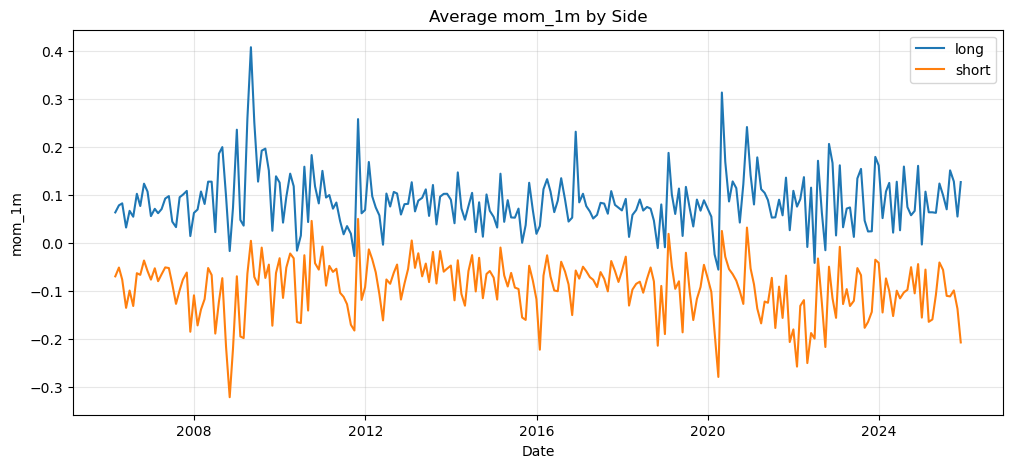

In [27]:
for col in factor_cols:
    plt.figure(figsize=(12, 5))
    for side in ["long", "short"]:
        tmp = factor_check[factor_check["side"] == side]
        if not tmp.empty:
            plt.plot(tmp["signal_date"], tmp[col], label=side)
    plt.title(f"Average {col} by Side")
    plt.xlabel("Date")
    plt.ylabel(col)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

### 13. Benchmark comparison vs S&P 500

In [28]:
sp = yf.download(
    "^GSPC",
    start="1996-01-01",
    end="2026-01-01",
    progress=False,
    auto_adjust=False
)

sp_price = sp[("Adj Close", "^GSPC")]

sp_monthly = (
    sp_price
    .resample("ME")
    .last()
    .pct_change()
    .dropna()
    .to_frame("sp_return")
    .reset_index()
    .rename(columns={"Date": "signal_date"})
)

sp_monthly["signal_date"] = pd.to_datetime(sp_monthly["signal_date"])
sp_monthly.head()

,signal_date,sp_return
0,1996-02-29,0.006934
1,1996-03-31,0.007917
2,1996-04-30,0.013431
3,1996-05-31,0.022853
4,1996-06-30,0.002257


In [29]:
portfolio_returns["signal_date"] = pd.to_datetime(portfolio_returns["signal_date"])
portfolio_returns = portfolio_returns.sort_values("signal_date").reset_index(drop=True)
sp_monthly = sp_monthly.sort_values("signal_date").reset_index(drop=True)

In [30]:
merged = pd.merge(
    portfolio_returns,
    sp_monthly,
    on="signal_date",
    how="inner"
)

print(merged.shape)
merged.head()

(168, 5)


,signal_date,execution_date,next_execution_date,portfolio_return,sp_return
0,2006-02-28,2006-03-01,2006-04-03,-0.007344,0.000453
1,2006-03-31,2006-04-03,2006-05-01,-0.002934,0.011096
2,2006-05-31,2006-06-01,2006-07-03,0.028994,-0.030917
3,2006-06-30,2006-07-03,2006-08-01,0.033679,0.000087
4,2006-07-31,2006-08-01,2006-09-01,0.000188,0.005086


In [31]:
merged["cum_aqr"] = (1 + merged["portfolio_return"]).cumprod()
merged["cum_sp"] = (1 + merged["sp_return"]).cumprod()

merged[["signal_date", "portfolio_return", "sp_return", "cum_aqr", "cum_sp"]].head()

,signal_date,portfolio_return,sp_return,cum_aqr,cum_sp
0,2006-02-28,-0.007344,0.000453,0.992656,1.000453
1,2006-03-31,-0.002934,0.011096,0.989743,1.011554
2,2006-05-31,0.028994,-0.030917,1.018440,0.980280
3,2006-06-30,0.033679,0.000087,1.052740,0.980365
4,2006-07-31,0.000188,0.005086,1.052938,0.985351


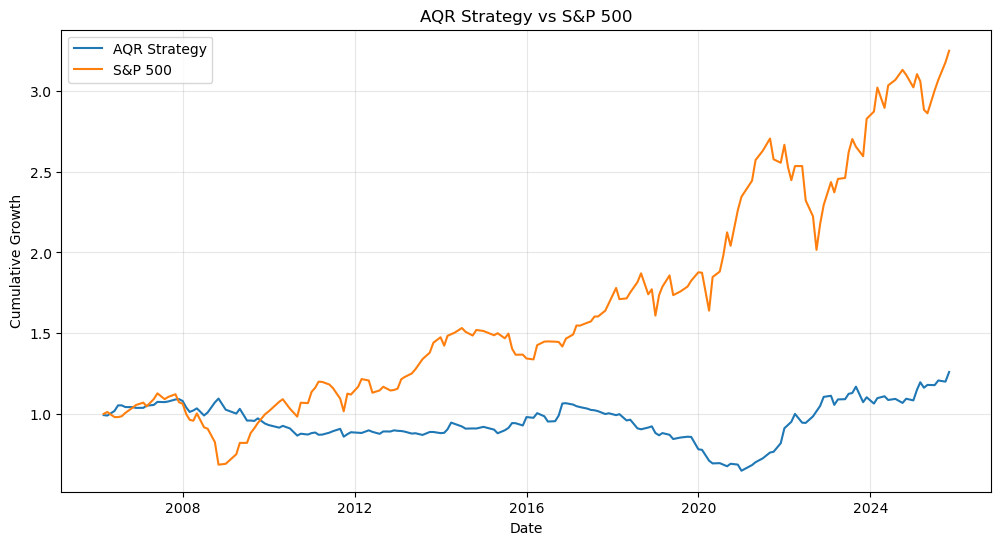

In [32]:
plt.figure(figsize=(12, 6))
plt.plot(merged["signal_date"], merged["cum_aqr"], label="AQR Strategy")
plt.plot(merged["signal_date"], merged["cum_sp"], label="S&P 500")
plt.title("AQR Strategy vs S&P 500")
plt.xlabel("Date")
plt.ylabel("Cumulative Growth")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [33]:
print("AQR Sharpe:", annualized_sharpe(merged["portfolio_return"]))
print("S&P 500 Sharpe:", annualized_sharpe(merged["sp_return"]))

AQR Sharpe: 0.2120756214147502
S&P 500 Sharpe: 0.6271436596297293


In [34]:
benchmark_summary = pd.DataFrame({
    "AQR Strategy": performance_summary(merged["portfolio_return"]),
    "S&P 500": performance_summary(merged["sp_return"]),
}).T

benchmark_summary

,mean_monthly,vol_monthly,ann_sharpe,positive_month_pct,max_drawdown
AQR Strategy,0.001810,0.029562,0.212076,0.523810,-0.408062
S&P 500,0.008028,0.044342,0.627144,0.636905,-0.391858


### 14. Turnover

In [35]:
membership_sets = (
    weights_at_E.groupby(["signal_date", "side"])["ticker"]
    .apply(set)
    .reset_index(name="ticker_set")
    .sort_values(["side", "signal_date"])
    .reset_index(drop=True)
)

membership_sets.head()

,signal_date,side,ticker_set
0,2006-02-28,long,"{BNS, ASR, DGICB, M, BHC, KEP, TD, BAC, LNT, L..."
1,2006-03-31,long,"{CATY, ASR, PBH, GTN, ORI, SFNC, COP, PB, CAR,..."
2,2006-04-28,long,"{ASR, AFG, HMC, TWX, CINF, KEP, COP, CVX, PB, ..."
3,2006-05-31,long,"{TRP, BIIB, DGICB, LPNT, NWN, GHC, TWX, AVA, C..."
4,2006-06-30,long,"{ASR, SFNC, CINF, PPL, EGN, FULT, RNR, MTN, HT..."


In [36]:
turnover_records = []

for side in membership_sets["side"].dropna().unique():
    tmp = membership_sets[membership_sets["side"] == side].sort_values("signal_date").reset_index(drop=True)

    for i in range(1, len(tmp)):
        prev_set = tmp.loc[i - 1, "ticker_set"]
        curr_set = tmp.loc[i, "ticker_set"]

        entered = len(curr_set - prev_set)
        exited = len(prev_set - curr_set)
        union_n = len(curr_set | prev_set)
        prev_n = len(prev_set)

        turnover_records.append({
            "signal_date": tmp.loc[i, "signal_date"],
            "side": side,
            "entered": entered,
            "exited": exited,
            "turnover_rate_vs_prev": (entered + exited) / prev_n if prev_n > 0 else np.nan,
            "jaccard_similarity": len(curr_set & prev_set) / union_n if union_n > 0 else np.nan,
        })

turnover_df = pd.DataFrame(turnover_records)
turnover_df.head()

,signal_date,side,entered,exited,turnover_rate_vs_prev,jaccard_similarity
0,2006-03-31,long,39,39,1.56,0.123596
1,2006-04-28,long,32,32,1.28,0.219512
2,2006-05-31,long,38,38,1.52,0.136364
3,2006-06-30,long,34,34,1.36,0.190476
4,2006-07-31,long,27,27,1.08,0.298701


In [37]:
turnover_df.groupby("side")[["turnover_rate_vs_prev", "jaccard_similarity"]].describe()

turnover_rate_vs_prev                                                    \
                      count      mean       std   min   25%   50%   75%   max   
side                                                                            
long                  237.0  1.337384  0.203898  0.76  1.20  1.36  1.48  1.76   
short                 237.0  1.264700  0.170611  0.52  1.16  1.28  1.36  1.76   

      jaccard_similarity                                                   \
                   count      mean       std      min       25%       50%   
side                                                                        
long               237.0  0.203156  0.076062  0.06383  0.149425  0.190476   
short              237.0  0.228671  0.066514  0.06383  0.190476  0.219512   

                           
            75%       max  
side                       
long   0.250000  0.449275  
short  0.265823  0.587302

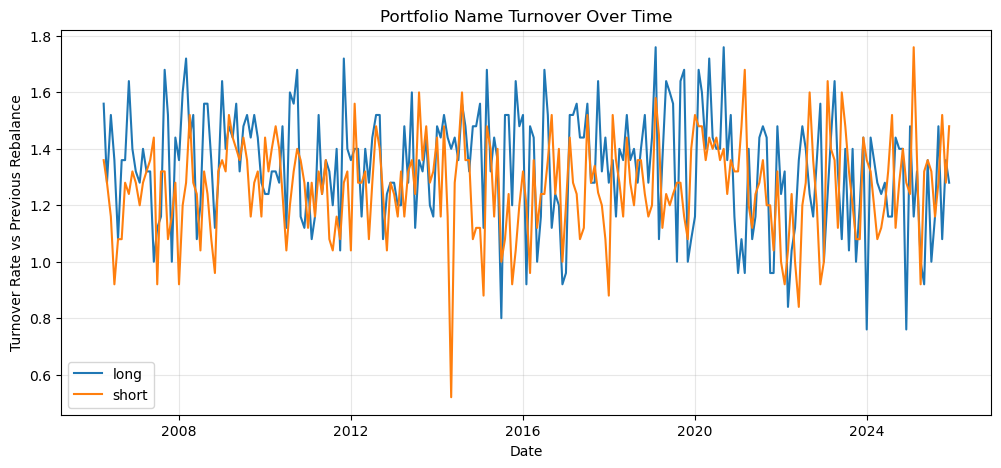

In [38]:
plt.figure(figsize=(12, 5))
for side in turnover_df["side"].dropna().unique():
    tmp = turnover_df[turnover_df["side"] == side]
    plt.plot(tmp["signal_date"], tmp["turnover_rate_vs_prev"], label=side)

plt.title("Portfolio Name Turnover Over Time")
plt.xlabel("Date")
plt.ylabel("Turnover Rate vs Previous Rebalance")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 15. A compact text summary cell for every model

In [39]:
print("=== MODEL SUMMARY ===")
print(f"Long-leg Sharpe: {annualized_sharpe(monthly_side_pivot['long']):.4f}")
print(f"Short-leg Sharpe: {annualized_sharpe(monthly_side_pivot['short']):.4f}")
print(f"Net Sharpe: {annualized_sharpe(monthly_side_pivot['net']):.4f}")
print(f"Max drawdown: {max_drawdown(monthly_side_pivot['net']):.4f}")
print(f"Average universe size: {universe_size['n_universe'].mean():.2f}")
print(f"Average long breadth: {breadth_pivot['long'].mean():.2f}")
print(f"Average short breadth: {breadth_pivot['short'].mean():.2f}")
print(f"Average long turnover: {turnover_df.loc[turnover_df['side']=='long', 'turnover_rate_vs_prev'].mean():.4f}")
print(f"Average short turnover: {turnover_df.loc[turnover_df['side']=='short', 'turnover_rate_vs_prev'].mean():.4f}")

=== MODEL SUMMARY ===
Long-leg Sharpe: 0.4817
Short-leg Sharpe: -0.2644
Net Sharpe: 0.0903
Max drawdown: -0.5436
Average universe size: 981.00
Average long breadth: 50.00
Average short breadth: 49.99
Average long turnover: 1.3374
Average short turnover: 1.2647
